# Lesson 4: Edges & Contours

## Notes for Task 1:
- cv.Canny(image: cv.Mat, low: int, high: int) --> Filters out weak edges from strong edges

## Task 1: Finding a Dog’s edges
1. Create a new python file and download the image of the dog below.
2. Convert the image to grayscale using cv.cvtColor() and apply a Gaussian blur with a kernel
size (5,5) using cv.GaussianBlur().
3. Pass the blurred image into canny_threshold_values() to retrieve the min and max values
for the canny threshold.
4. Use cv.Canny() to detect the image edges. Display your result.
5. Increase/decrease the kernel size of the Gaussian Blur and see what happens.

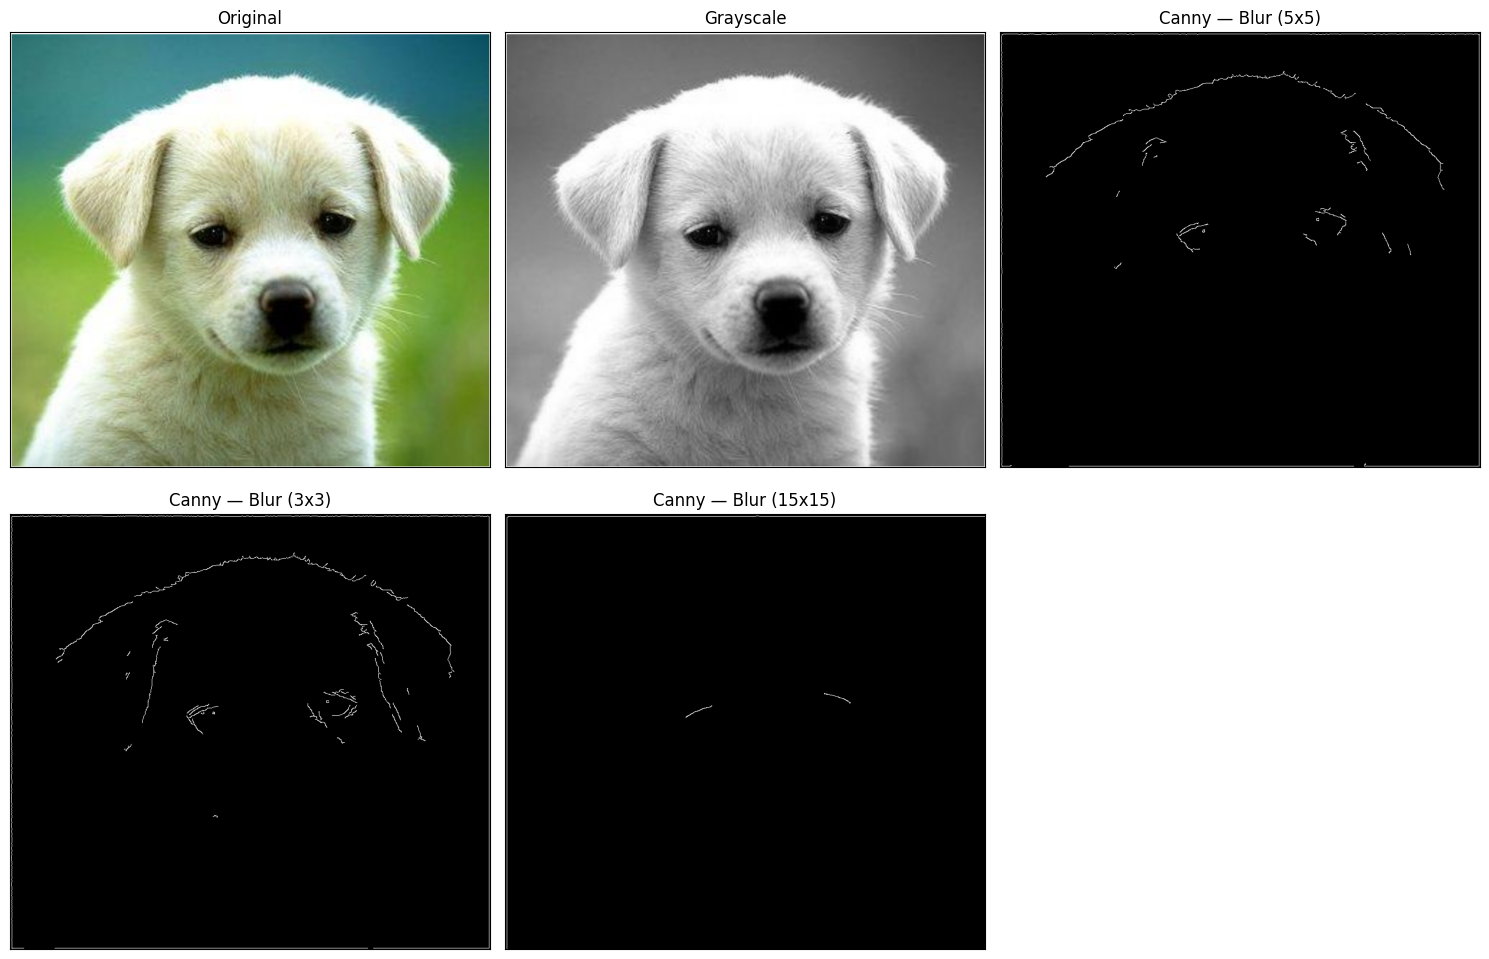

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def canny_threshold_values(img, deviation=0.33):
    """Calculate reasonable Canny threshold values using median intensity.
    Uses the median pixel value and a deviation to set min/max thresholds."""
    # Find the median pixel intensity across the entire image
    avgIntense = np.median(img)
    # Set min threshold 33% below median, max threshold 33% above
    minVal = avgIntense * (1 - deviation)
    maxVal = avgIntense * (1 + deviation)
    return minVal, maxVal

# Read the dog image in BGR format
img = cv.imread("FASTR_Dog.png")

# Convert BGR to RGB so matplotlib displays colours correctly
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Convert to grayscale — Canny only works on single-channel intensity images
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Apply Gaussian blur with different kernel sizes to compare
# Blur reduces high-frequency noise that would be falsely detected as edges
blurred_5 = cv.GaussianBlur(gray, (5, 5), 0)   # Medium blur
blurred_3 = cv.GaussianBlur(gray, (3, 3), 0)    # Light blur — keeps more detail and noise
blurred_15 = cv.GaussianBlur(gray, (15, 15), 0)  # Heavy blur — removes detail and noise

# Calculate Canny threshold values from the (5,5) blurred image
minVal, maxVal = canny_threshold_values(blurred_5)

# Apply Canny edge detection to each blur level
# Canny finds pixels with high intensity gradients (sudden colour changes) = edges
edges_5 = cv.Canny(blurred_5, minVal, maxVal)    # Balanced edges
edges_3 = cv.Canny(blurred_3, minVal, maxVal)    # More edges, including noisy ones
edges_15 = cv.Canny(blurred_15, minVal, maxVal)  # Fewer edges, only strong ones survive

# Create a 2x3 subplot to compare all results
plt.figure(figsize=(15, 10))

# Row 1: Original, Grayscale, and the standard (5x5) Canny result
plt.subplot(2, 3, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.xticks([])
plt.yticks([])

plt.subplot(2, 3, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.xticks([])
plt.yticks([])

plt.subplot(2, 3, 3)
plt.imshow(edges_5, cmap="gray")
plt.title("Canny — Blur (5x5)")
plt.xticks([])
plt.yticks([])

# Row 2: Comparing different blur levels on Canny output
plt.subplot(2, 3, 4)
plt.imshow(edges_3, cmap="gray")
plt.title("Canny — Blur (3x3)")
plt.xticks([])
plt.yticks([])

plt.subplot(2, 3, 5)
plt.imshow(edges_15, cmap="gray")
plt.title("Canny — Blur (15x15)")
plt.xticks([])
plt.yticks([])

# Arrange subplots neatly with no overlap
plt.tight_layout()
plt.show()